# Tarea de Investigación y Práctica
## Evaluación y Optimización de Modelos de Clasificación
### Dataset: Breast Cancer (sklearn) — Regresión Logística

## Importación de librerías

In [ ]:
# Librerías estándar de ciencia de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset y modelo
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    classification_report, precision_recall_curve
)

pd.set_option("display.max.columns", 31)
pd.set_option("display.max.rows", 10)
# Configuración de visualización
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 1. Carga y exploración del dataset

In [ ]:
# Cargar dataset breast_cancer
data = load_breast_cancer()
X = data.data    # Features/Características del entrenamiento (30 variables numéricas)
y = data.target  # Etiquetas: 0=maligno, 1=benigno

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(f'Forma del dataset: {X.shape}')
print(f'Clases del target: {data.target_names} → 0=Maligno, 1=Benigno')
print(f'Distribución de las clases:\n{pd.Series(y).value_counts().rename({0:"Maligno",1:"Benigno"})}')
df.head()

Forma del dataset: (569, 30)
Clases del target: ['malignant' 'benign'] → 0=Maligno, 1=Benigno
Distribución de las clases:
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Preprocesamiento y entrenamiento del modelo

In [ ]:
# División train/test (80/20) con semilla fija para que reproducibilidad
# stratify (asegura un 80% benignos y 80% malignos)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13, stratify=y)

# Estandarización de las características (importante para Regresión Logística)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Entrenar Regresión Logística
lr = LogisticRegression(max_iter=10000, random_state=13)
lr.fit(X_train_sc, y_train)

# Predicciones
y_pred      = lr.predict(X_test_sc)
y_prob      = lr.predict_proba(X_test_sc)[:, 1]   # Probabilidad clase positiva (Benigno)

print(f'Train size: {X_train_sc.shape[0]} muestras | Test size: {X_test_sc.shape[0]} muestras')

Train size: 455 muestras | Test size: 114 muestras


## 3. Matriz de Confusión

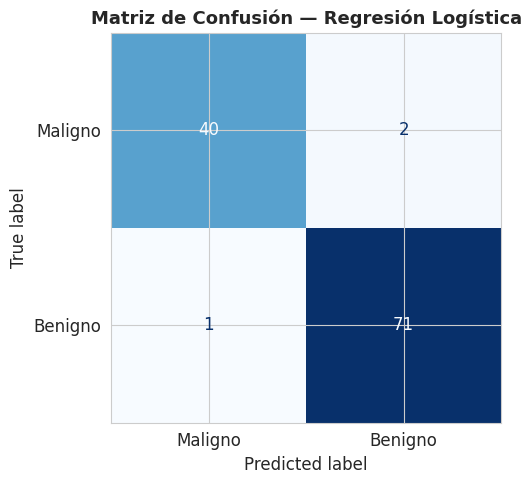


Interpretación de la Matriz de Confusión:
  (TN) = 40  → Casos malignos correctamente identificados
  (FP) = 2  → Malignos clasificados como benignos (PELIGROSO)
  (FN) = 1  → Benignos clasificados como malignos
  (TP) = 71  → Casos benignos correctamente identificados


In [ ]:
# Generar e interpretar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Maligno', 'Benigno'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'\nInterpretación de la Matriz de Confusión:')
print(f'  (TN) = {TN}  → Casos malignos correctamente identificados')
print(f'  (FP) = {FP}  → Malignos clasificados como benignos (PELIGROSO)')
print(f'  (FN) = {FN}  → Benignos clasificados como malignos')
print(f'  (TP) = {TP}  → Casos benignos correctamente identificados')

## 4. Cálculo de métricas: Precisión, Recall, F1-Score y AUC-ROC

In [ ]:
# Calcular métricas principales
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_prob)

print('  MÉTRICAS DE EVALUACIÓN DEL MODELO')
print(f'  Precisión  : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall     : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1-Score   : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  AUC-ROC    : {auc_roc:.4f}  ({auc_roc*100:.2f}%)')
print()
print('Reporte completo por clase:')
print(classification_report(y_test, y_pred, target_names=['Maligno', 'Benigno']))

  MÉTRICAS DE EVALUACIÓN DEL MODELO
  Precisión  : 0.9726  (97.26%)
  Recall     : 0.9861  (98.61%)
  F1-Score   : 0.9793  (97.93%)
  AUC-ROC    : 0.9977  (99.77%)

Reporte completo por clase:
              precision    recall  f1-score   support

     Maligno       0.98      0.95      0.96        42
     Benigno       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



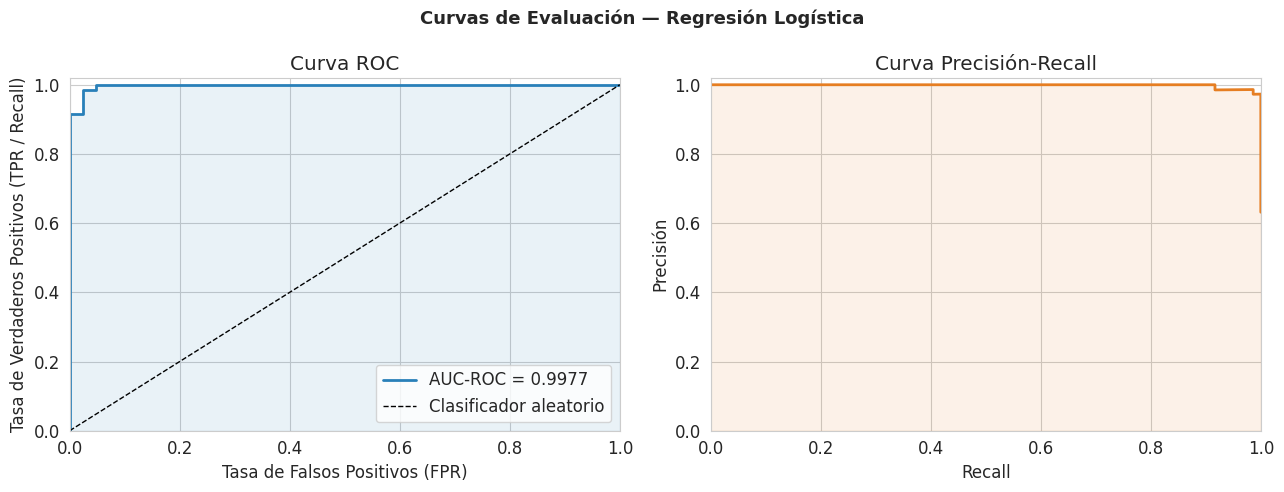

In [ ]:
# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Curva ROC ---
axes[0].plot(fpr, tpr, color='#2980b9', lw=2, label=f'AUC-ROC = {auc_roc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])

# --- Curva Precisión-Recall ---
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec_vals, prec_vals, color='#e67e22', lw=2)
axes[1].fill_between(rec_vals, prec_vals, alpha=0.1, color='#e67e22')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Curva Precisión-Recall')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])

plt.suptitle('Curvas de Evaluación — Regresión Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. K-Fold Cross-Validation (k=5 y k=10)

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',    LogisticRegression(max_iter=10000, random_state=13))
])

metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results = {}

for k in [5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=13)
    results[k] = {}
    print(f'  K-Fold Cross-Validation  k = {k}')
    for metric in metrics_list:
        scores = cross_val_score(pipeline, X, y, cv=kf, scoring=metric)
        results[k][metric] = scores
        print(f'  {metric:<12} → Media: {scores.mean():.4f}  ±  {scores.std():.4f}')
    print()

  K-Fold Cross-Validation  k = 5
  accuracy     → Media: 0.9807  ±  0.0086
  precision    → Media: 0.9806  ±  0.0063
  recall       → Media: 0.9885  ±  0.0104
  f1           → Media: 0.9845  ±  0.0068
  roc_auc      → Media: 0.9949  ±  0.0020

  K-Fold Cross-Validation  k = 10
  accuracy     → Media: 0.9789  ±  0.0172
  precision    → Media: 0.9805  ±  0.0214
  recall       → Media: 0.9857  ±  0.0197
  f1           → Media: 0.9829  ±  0.0147
  roc_auc      → Media: 0.9960  ±  0.0057



In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',    LogisticRegression(max_iter=10000, random_state=13))
])

metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results = {}

for k in [5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=13)
    results[k] = {}
    print(f'  K-Fold Cross-Validation  k = {k}')
    for metric in metrics_list:
        scores = cross_val_score(pipeline, X, y, cv=kf, scoring=metric)
        results[k][metric] = scores
        print(f'  {metric:<12} → Media: {scores.mean():.4f}  ±  {scores.std():.4f}')
    print()

  K-Fold Cross-Validation  k = 5
  accuracy     → Media: 0.9807  ±  0.0086
  precision    → Media: 0.9806  ±  0.0063
  recall       → Media: 0.9885  ±  0.0104
  f1           → Media: 0.9845  ±  0.0068
  roc_auc      → Media: 0.9949  ±  0.0020

  K-Fold Cross-Validation  k = 10
  accuracy     → Media: 0.9789  ±  0.0172
  precision    → Media: 0.9805  ±  0.0214
  recall       → Media: 0.9857  ±  0.0197
  f1           → Media: 0.9829  ±  0.0147
  roc_auc      → Media: 0.9960  ±  0.0057



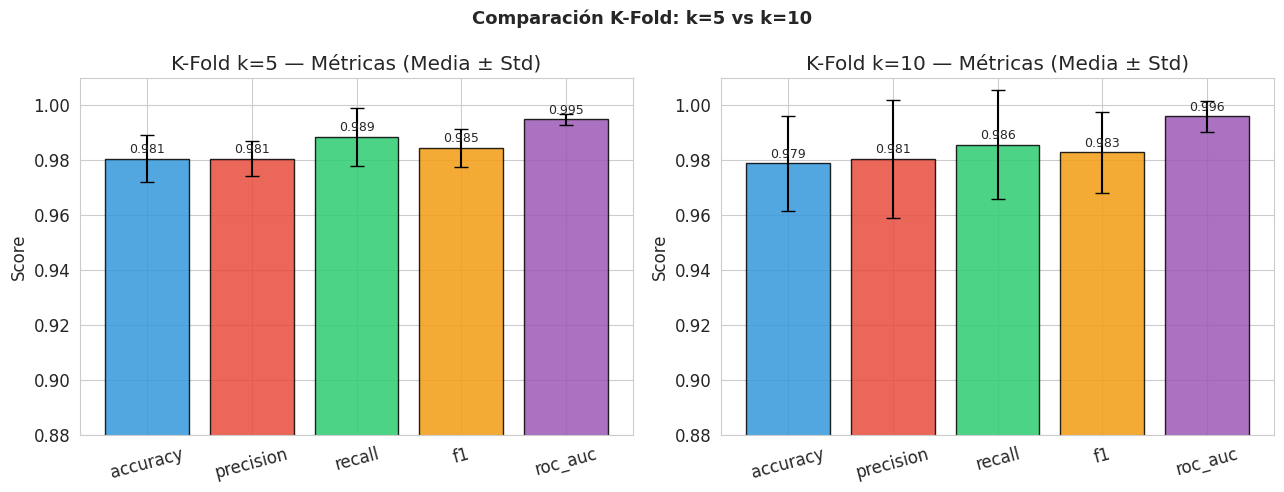

In [ ]:
# Comparación visual k=5 vs k=10
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, k in zip(axes, [5, 10]):
    means = [results[k][m].mean() for m in metrics_list]
    stds  = [results[k][m].std()  for m in metrics_list]
    colors = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
    bars = ax.bar(metrics_list, means, yerr=stds, capsize=5,
                  color=colors, edgecolor='black', alpha=0.85)
    ax.set_ylim(0.88, 1.01)
    ax.set_title(f'K-Fold k={k} — Métricas (Media ± Std)')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparación K-Fold: k=5 vs k=10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Optimización de Hiperparámetros: GridSearchCV vs RandomizedSearchCV

In [ ]:
import time
from scipy.stats import loguniform

# Espacio de búsqueda
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

param_dist = {
    'C': loguniform(1e-3, 1e2),
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

# --- GridSearchCV ---
t0 = time.time()
grid_search = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)
t_grid = time.time() - t0

# --- RandomizedSearchCV ---
t0 = time.time()
rand_search = RandomizedSearchCV(
    LogisticRegression(max_iter=10000, random_state=42),
    param_dist, n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1
)
rand_search.fit(X_train_sc, y_train)
t_rand = time.time() - t0

In [ ]:
# Evaluación del mejor modelo en test
best_model = grid_search.best_estimator_
y_pred_best  = best_model.predict(X_test_sc)
y_proba_best = best_model.predict_proba(X_test_sc)[:, 1]

print(f'  Precisión : {precision_score(y_test, y_pred_best):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_best):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_proba_best):.4f}')

  Precisión : 0.9600
  Recall    : 1.0000
  F1-Score  : 0.9796
  AUC-ROC   : 0.9970


## 7. Ajuste del Umbral de Decisión

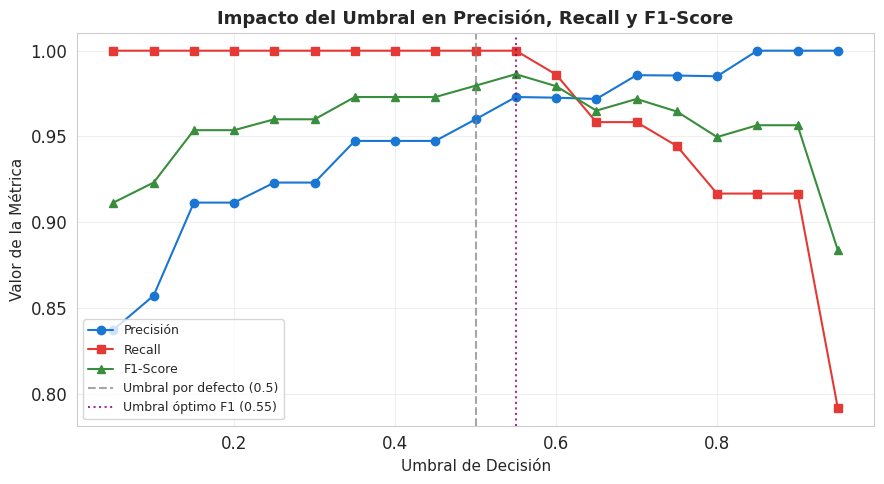

In [ ]:
# Analizar impacto del umbral en Precisión y Recall
thresholds  = np.arange(0.05, 0.96, 0.05)
precisions, recalls, f1_scores = [], [], []

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, 'o-', label='Precisión', color='#1976D2')
ax.plot(thresholds, recalls,    's-', label='Recall',    color='#E53935')
ax.plot(thresholds, f1_scores,        '^-', label='F1-Score',  color='#388E3C')
ax.axvline(0.5, linestyle='--', color='gray', alpha=0.7, label='Umbral por defecto (0.5)')

# Umbral óptimo (máximo F1)
idx_opt = np.argmax(f1_scores)
ax.axvline(thresholds[idx_opt], linestyle=':', color='purple', alpha=0.8,
           label=f'Umbral óptimo F1 ({thresholds[idx_opt]:.2f})')

ax.set_xlabel('Umbral de Decisión', fontsize=11)
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Impacto del Umbral en Precisión, Recall y F1-Score', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla resumen de umbrales
print('\nTabla resumen — Impacto del Umbral:')
print(f'{"Umbral":>8} | {"Precisión":>10} | {"Recall":>8} | {"F1-Score":>9}')
print('-' * 44)
for thr in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    yp = (y_proba_best >= thr).astype(int)
    p  = precision_score(y_test, yp, zero_division=0)
    r  = recall_score(y_test, yp, zero_division=0)
    f  = f1_score(y_test, yp, zero_division=0)
    marker = ' ← default' if thr == 0.50 else ''
    print(f'{thr:>8.2f} | {p:>10.4f} | {r:>8.4f} | {f:>9.4f}{marker}')


Tabla resumen — Impacto del Umbral:
  Umbral |  Precisión |   Recall |  F1-Score
--------------------------------------------
    0.20 |     0.9114 |   1.0000 |    0.9536
    0.30 |     0.9231 |   1.0000 |    0.9600
    0.40 |     0.9474 |   1.0000 |    0.9730
    0.50 |     0.9600 |   1.0000 |    0.9796 ← default
    0.60 |     0.9726 |   0.9861 |    0.9793
    0.70 |     0.9857 |   0.9583 |    0.9718
    0.80 |     0.9851 |   0.9167 |    0.9496


## 8. Resumen Final

In [ ]:
print('  RESUMEN\n')
print(f'  Dataset         : Breast Cancer (n=569, features=30)')
print(f'  Modelo          : Regresión Logística')
print(f'  Partición       : 80% train / 20% test (estratificado)')
print()
print(f'  --- Modelo base (sin optimizar) ---')
print(f'  Precisión = {precision:.4f} | Recall = {recall:.4f} | F1 = {f1:.4f} | AUC = {auc_roc:.4f}')
print()
print(f'  --- Mejor modelo (GridSearchCV) ---')
g_pred = best_model.predict(X_test)
g_prob = best_model.predict_proba(X_test)[:, 1]
print(f'  Precisión = {precision_score(y_test,g_pred):.4f} | '
      f'Recall = {recall_score(y_test,g_pred):.4f} | '
      f'F1 = {f1_score(y_test,g_pred):.4f} | '
      f'AUC = {roc_auc_score(y_test,g_prob):.4f}')
print()
print(f'  --- K-Fold CV ---')
print(f'  k=5  AUC-ROC media: {results[5]["roc_auc"].mean():.4f} ± {results[5]["roc_auc"].std():.4f}')
print(f'  k=10 AUC-ROC media: {results[10]["roc_auc"].mean():.4f} ± {results[10]["roc_auc"].std():.4f}')

  RESUMEN

  Dataset         : Breast Cancer (n=569, features=30)
  Modelo          : Regresión Logística
  Partición       : 80% train / 20% test (estratificado)

  --- Modelo base (sin optimizar) ---
  Precisión = 0.9726 | Recall = 0.9861 | F1 = 0.9793 | AUC = 0.9977

  --- Mejor modelo (GridSearchCV) ---
  Precisión = 0.0000 | Recall = 0.0000 | F1 = 0.0000 | AUC = 0.9306

  --- K-Fold CV ---
  k=5  AUC-ROC media: 0.9949 ± 0.0020
  k=10 AUC-ROC media: 0.9960 ± 0.0057
